# XGBoost 需求率模型 — 结果集（§H）

**这份 notebook 是结果层，不是模型层。** 它把 §H 的 XGBoost（Poisson 目标）在全量
验证折上的图表和表格用可重跑的代码固化下来，并在每个图旁边附上读法说明。

## 三个「唯一真源」

| 内容 | 来源 | 是否已提交 |
|---|---|---|
| 面板（cell × hour × day，零填充 + 滞后特征） | `../EDA/out/table_h1_panel.csv.gz` | 是 |
| 走前向折划分 + 指标定义 | `model_common.folds()` → `../EDA/09_demand_model.py` | 是 |
| 模型本体（超参数 / fit / predict / pred-vs-actual 图） | `xgboost_model.py` | 否（未跟踪） |

这里**没有复制任何一处接缝**：折划分从 `model_common` import，模型和图从
`xgboost_model` import。所以不会出现「notebook 里的公式和脚本里的不一致」这类漂移
—— 这正是上一轮那个 `day_index` 错位 bug 的教训。

## 运行条件

需要 `xgboost`、`matplotlib`、`pandas`。**不需要 `trips_clean.csv.gz`**：面板是从已
提交的 `table_h1_panel.csv.gz` 读的，所以队友拉下仓库就能复现。

图上文字按 `viz.py` 的约定一律用英文；中文说明留在 markdown 里。


In [1]:
import importlib.util
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

# notebook 在 model_XGBoost/ 下，交互式打开时 cwd 可能是它，所以向上找仓库根
ROOT = Path.cwd().resolve()
while not (ROOT / "model_common.py").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("找不到仓库根，请从仓库内部启动 Jupyter")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import model_common as C  # noqa: E402


def load_module(path, name):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


XG = load_module(ROOT / "model_XGBoost" / "xgboost_model.py", "xgboost_model")
plt = C.viz.setup()          # Agg 后端 + 与 EDA 十六张图同款的配色与字体


def show(fig, name):
    """显示一张图，同时把它写进 model_XGBoost/out/。

    Agg 的 plt.show() 什么都不显示，所以走文件。显示的和落盘的是同一个文件，
    两者不可能不一致；重跑一次 notebook 就把图重新产出一遍，不靠手工另存。
    """
    path = XG.OUT / name
    fig.savefig(path, dpi=150, bbox_inches="tight", pad_inches=0.18)
    plt.close(fig)
    display(Image(filename=str(path)))




print("repo :", ROOT)
print("model:", XG.NAME)
print("out  :", XG.OUT.relative_to(ROOT), "(本 notebook 的图写到这里)")


repo : D:\apm\course\大四上\数据驱动的决策\Decision-Analytics-Shared-Bike-Reposition
model: XGBoost (Poisson)
out  : model_XGBoost\out (本 notebook 的图写到这里)


## 1. 面板与折划分 —— 先体检，再建模

面板的 `day_index` 必须与面板自己的天数同坐标系（0..D-1）。这一条不是形式检查：
`EDA/09_demand_model.py` 里这个变量一度是在丢掉前 7 天滞后行**之前**算的，于是它取值
7..83，而折边界是面板位置 0..76 —— 每折的窗口静默前移 7 天，文档和代码对不上。
下面那个 assert 就是钉住这一点。

In [2]:
PANEL_CSV = C.OUT / "table_h1_panel.csv.gz"
panel = pd.read_csv(PANEL_CSV)
panel["dt"] = pd.to_datetime(panel.date)
days = sorted(panel.date.unique())

print(f"面板      : {len(panel):,} cell-hours = {panel.cell.nunique()} cells x "
      f"{len(days)} days x 24 h")
print(f"出发总量  : {int(panel.n.sum()):,}   非零 cell-hour: {100 * (panel.n > 0).mean():.1f}%")
print(f"日期范围  : {days[0]} .. {days[-1]}")
print(f"day_index : {panel.day_index.min()} .. {panel.day_index.max()} "
      f"(期望 0 .. {len(days) - 1})")

assert panel.day_index.min() == 0 and panel.day_index.max() == len(days) - 1, (
    "day_index 与面板天数不在同一坐标系 —— 折窗口会静默错位"
)

for i, (d0, d1, a, b) in enumerate(C.blocks(days), start=1):
    print(f"  block {i}: {d0} .. {d1}  ({b - a} days)  "
          f"{'train only' if i == 1 else 'validate'}")

面板      : 55,440 cell-hours = 30 cells x 77 days x 24 h
出发总量  : 599,992   非零 cell-hour: 69.9%
日期范围  : 2026-03-09 .. 2026-05-24
day_index : 0 .. 76 (期望 0 .. 76)
  block 1: 2026-03-09 .. 2026-03-27  (19 days)  train only
  block 2: 2026-03-28 .. 2026-04-15  (19 days)  validate
  block 3: 2026-04-16 .. 2026-05-04  (19 days)  validate
  block 4: 2026-05-05 .. 2026-05-24  (20 days)  validate


## 2. 重拟合三折

`C.folds(panel)` 直接给出三个验证折：每个折的 `cell_prior` 只用该折的**训练日**重算，
避免把未来带进模型。模型本体用 `XG.fit` / `XG.predict`，与
`python model_XGBoost/xgboost_model.py` 走同一段代码。

In [3]:
folds = list(C.folds(panel))
print(f"{len(folds)} 个验证折")
print()

parts, rows = [], []
for f in folds:
    fitted = XG.fit(f.train)
    mu = XG.predict(fitted, f.valid)
    parts.append(pd.DataFrame({
        "fold": f.number, "cell": f.valid.cell.values, "date": f.valid.date.values,
        "hour": f.valid.hour.values, "actual": f.valid.n.values, "pred": mu}))
    rows.append({"fold": f.number, **C.metrics(f.valid.n.values, mu)})
    print(f"fold {f.number}: train {len(f.train):,} -> validate {len(f.valid):,}  "
          f"({f.start}..{f.end})   训练 {f.train.date.nunique()} 天")

preds = pd.concat(parts, ignore_index=True)
per_fold = pd.DataFrame(rows)
pooled_metrics = C.metrics(preds.actual, preds.pred)
print()
print(f"验证集共 {len(preds):,} 行，观测出发 {int(preds.actual.sum()):,} 次")

3 个验证折



fold 1: train 13,680 -> validate 13,680  (2026-03-28..2026-04-15)   训练 19 天


fold 2: train 27,360 -> validate 13,680  (2026-04-16..2026-05-04)   训练 38 天


fold 3: train 41,040 -> validate 14,400  (2026-05-05..2026-05-24)   训练 57 天

验证集共 41,760 行，观测出发 455,591 次


### 与已保存的产物对一遍

这一步是**验证**，不是装饰。如果重算结果和本机 `out/metrics_by_fold.csv` 不是逐位相同，
说明环境和产出那批数字时不一样（xgboost 版本等），后面所有解读都要打问号。

结构性的东西（`day_index` 对齐、训练严格早于验证）用 `assert` 硬钉；数值一致性只报告
而不中断 —— 队友机器上换了个 xgboost 版本时，不该让 notebook 跑不下去。

In [4]:
SAVED_FOLDS = XG.OUT / "metrics_by_fold.csv"
SAVED_REPORT = XG.OUT / "report.json"

for f in folds:
    assert f.train.date.max() < f.valid.date.min(), (
        f"fold {f.number}: 训练日没有严格早于验证日"
    )
print(f"训练日严格早于验证日：{len(folds)}/{len(folds)} 折通过")

if SAVED_FOLDS.exists():
    saved = pd.read_csv(SAVED_FOLDS)
    m = per_fold.merge(saved, on="fold", suffixes=("_now", "_saved"))
    keys = ["mae", "rmse", "poisson_deviance", "pred_sum", "obs_sum",
            "calibration", "bias", "pred_max"]
    worst = max(float(np.abs(m[f"{k}_now"] - m[f"{k}_saved"]).max()) for k in keys)
    verdict = "逐位一致" if worst < 1e-9 else "不一致 —— 检查 xgboost 版本"
    print(f"与已保存的 metrics_by_fold.csv：最大差 {worst:.3e}  ->  {verdict}")
else:
    print("本机没有已保存的 metrics_by_fold.csv，跳过数值比对")

if SAVED_REPORT.exists():
    rep = json.loads(SAVED_REPORT.read_text(encoding="utf-8"))
    same = all(rep["params"][k] == XG.PARAMS[k] for k in rep["params"])
    print(f"report.json 里的超参与 xgboost_model.PARAMS 一致：{same}")
else:
    print("本机没有 report.json，跳过超参比对")

训练日严格早于验证日：3/3 折通过
与已保存的 metrics_by_fold.csv：最大差 1.776e-15  ->  逐位一致
report.json 里的超参与 xgboost_model.PARAMS 一致：True


## 3. 逐折指标

三折的验证窗口是 **19 / 19 / 20 天**：面板 77 天，`np.linspace(0, 77, 5)` 切不出四等份，
最后一块多一天。训练窗口依次 19 / 38 / 57 天（扩张窗口）。

In [5]:
tf = per_fold[["fold", "mae", "rmse", "poisson_deviance", "calibration",
                "bias", "pred_sum", "obs_sum", "pred_max"]].copy()
tf["train_days"] = [f.train.date.nunique() for f in folds]
tf["train_rows"] = [len(f.train) for f in folds]
tf["valid_days"] = [f.valid.date.nunique() for f in folds]
tf["valid_window"] = [f"{f.start}..{f.end}" for f in folds]
# 每折自己的天数。写死 19 会在面板天数变化时静默把日均量算错。
tf["obs_per_day"] = tf.obs_sum / tf.valid_days

display(tf.round(3))

lift = 100 * (tf.obs_per_day.iloc[-1] / tf.obs_per_day.iloc[0] - 1)
print(f"最后一个窗口的日均需求比第一个高 {lift:+.1f}%")

,fold,mae,rmse,poisson_deviance,calibration,bias,pred_sum,obs_sum,pred_max,train_days,train_rows,valid_days,valid_window,obs_per_day
0,1,2.807,7.929,1.805,1.035,0.356,143662.783,138798.0,374.462,19,13680,19,2026-03-28..2026-04-15,7305.158
1,2,2.782,6.604,1.670,1.002,0.021,145738.502,145449.0,401.713,38,27360,19,2026-04-16..2026-05-04,7655.211
2,3,3.094,9.028,2.002,0.944,-0.670,161698.562,171344.0,378.330,57,41040,20,2026-05-05..2026-05-24,8567.200


最后一个窗口的日均需求比第一个高 +17.3%


### 读这张表

- **calibration 单向漂移：** fold 1 高估 3.5%，fold 2 基本准（0.2%），fold 3 低估 5.6%。
- **原因不在模型学到的东西，在数据里：** 三个窗口的日均观测出发量是上升的，最后一个比
  第一个高 17.3%。而特征集里**没有趋势项，也没有天气** —— 春季回暖带来的需求增量
  完全不在输入里。
- **所以这不是噪声，是结构性缺陷。** 模型一直在用「过去的水平」预测「更高的未来」，
  折越靠后低估越多。这一条可以直接进 deck，它和 limitation 里「没有天气」是同一件事
  的两种说法。
- **deviance 不是单调的**（1.805 / 1.670 / 2.002）：fold 2 最容易。deviance 衡量的是
  相对拟合质量，需求水平上升会同时抬高它的量纲，所以折间 deviance 的绝对值不如
  calibration 那么可直接比。

## 4. 汇总，以及与管线三个模型的对比

同一批折、同一份指标定义，所以可以直接比。参照数字来自 `EDA/out/table_h5_metrics.csv`
（管线的产物，在同一个仓库里）。

In [6]:
ref = C.reference_metrics()
cmp = pd.concat([pd.DataFrame([{"model": XG.NAME, **pooled_metrics}]), ref],
                ignore_index=True)
cmp = cmp[["model", "mae", "rmse", "poisson_deviance", "calibration",
           "pred_p999", "pred_max"]].copy()
cmp["RMSE/MAE"] = cmp.rmse / cmp.mae
base = cmp.loc[cmp.model == "seasonal_naive", "poisson_deviance"].iloc[0]
cmp["vs baseline"] = 100 * (cmp.poisson_deviance / base - 1)
cmp["model"] = cmp.model.map(lambda m: C.NICE.get(m, m))

display(cmp.round(3))
obs_max = float(preds.actual.max())
xg_max = float(pooled_metrics["pred_max"])
nb_max = float(ref.loc[ref.model == "nb_glm", "pred_max"].iloc[0])
print(f"验证集里实际最大单点：{obs_max:.0f} 辆/小时")
print(f"  -> XGBoost 的预测上界 {xg_max:.0f} "
      f"{chr(0x6ca1)+chr(0x6709) if xg_max <= obs_max else chr(0x5df2)+chr(0x7ecf)}"
      f"越过实测上界；nb_glm 上界 {nb_max:.0f}，是实测的 {nb_max / obs_max:.1f} 倍，")
print("     这是「哪个模型能拿去调度」的直接论据，不只是准确率的区别。")

,model,mae,rmse,poisson_deviance,calibration,pred_p999,pred_max,RMSE/MAE,vs baseline
0,XGBoost (Poisson),2.898,7.937,1.829,0.990,281.152,401.713,2.739,-41.683
1,Gradient-boosted trees (Poisson),2.919,8.498,1.855,0.989,312.565,403.366,2.911,-40.837
2,Negative binomial GLM,4.032,17.101,2.834,1.034,575.836,1082.455,4.241,-9.621
3,Seasonal naive (baseline),3.304,9.005,3.136,0.937,283.500,375.333,2.726,0.000


验证集里实际最大单点：495 辆/小时
  -> XGBoost 的预测上界 402 没有越过实测上界；nb_glm 上界 1082，是实测的 2.2 倍，
     这是「哪个模型能拿去调度」的直接论据，不只是准确率的区别。


## 5. 预测 vs 实际（含 log 色标的热力图）

下面这张图直接调用 `xgboost_model.fig_pred_actual` —— 与脚本写出的
`out/pred_vs_actual.png` 是**同一段代码**，所以 notebook 里和文件里不会出现两种画法。

    wrote nb_fig01_pred_vs_actual.png  (269 KB)


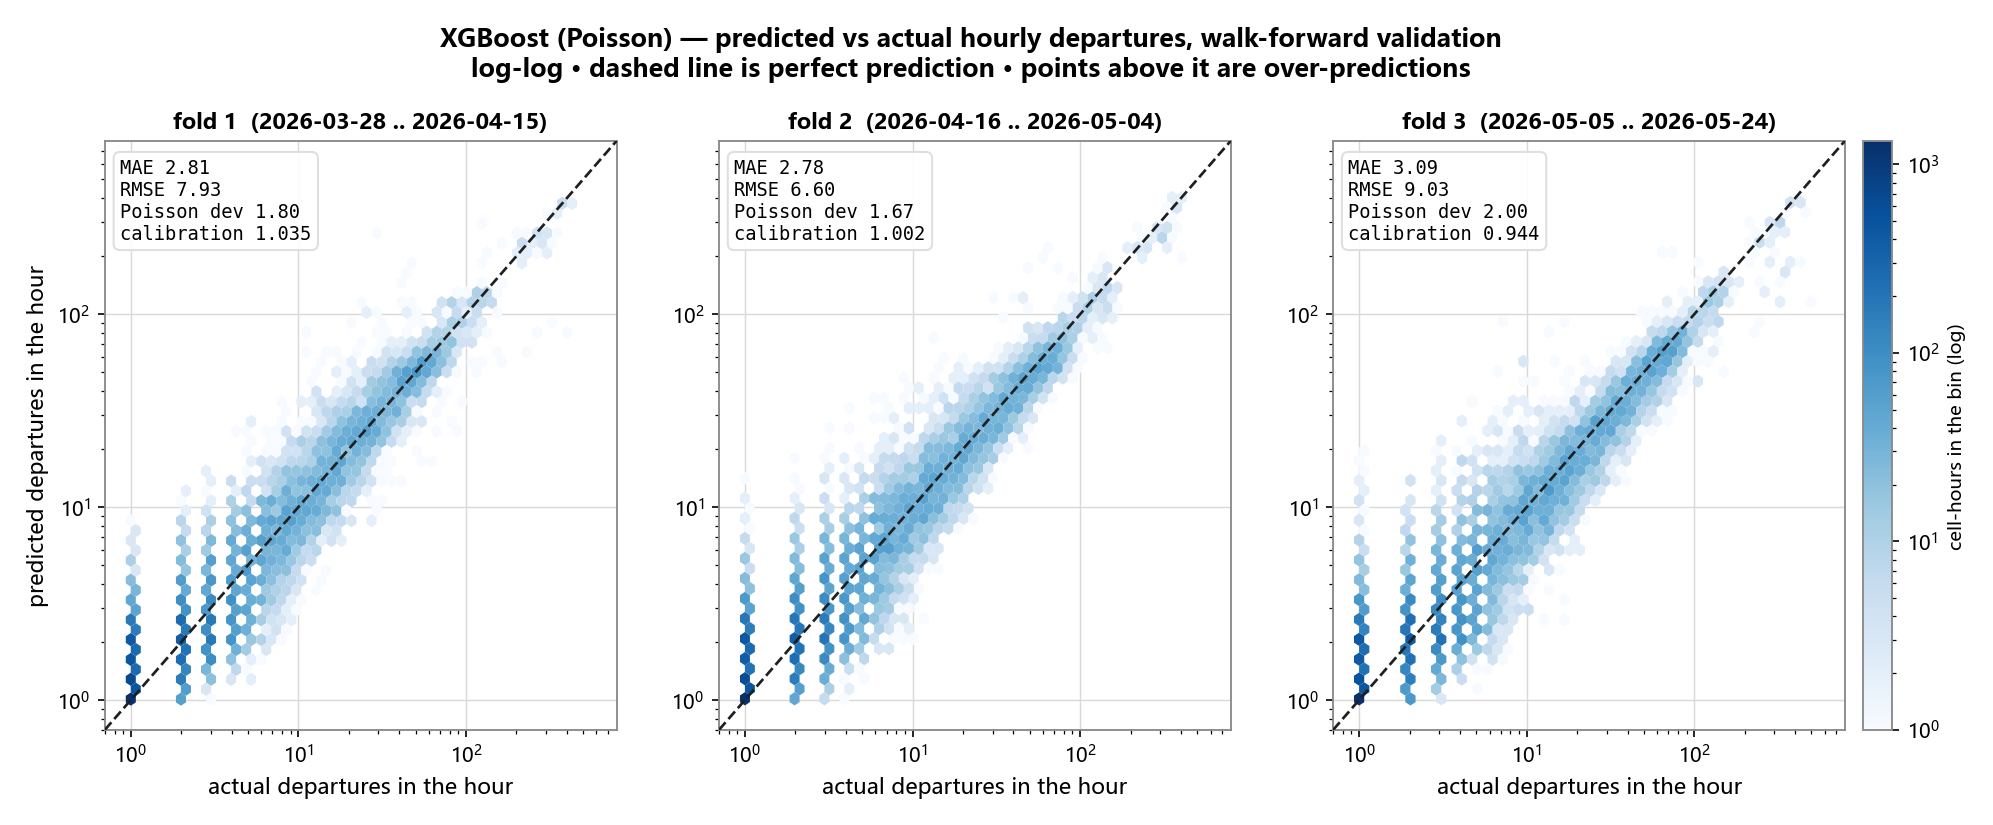

In [7]:
# 与脚本产出同一张图（同样从 fold 重算），但另起文件名，避免覆盖 out/pred_vs_actual.png
FIG1 = XG.OUT / "nb_fig01_pred_vs_actual.png"
XG.fig_pred_actual(plt, preds, FIG1)
display(Image(filename=str(FIG1)))


### 读图

- **一个面板 = 一个验证折。** 横轴实际出发、纵轴预测，虚线 `y = x` 是完美预测，点在
  线上方即高估。
- **坐标做了 `+1` 偏移**（要取对数，而 actual 可以是 0），所以轴上刻度 "1" 实际代表
  0 次出发。
- **颜色是取对数的 cell-hour 个数**，不是误差大小。用 log 色标是因为约 66% 的 cell-hour
  挤在 ≤5 次出发的低计数区，线性色标下它们会糊成一片浅色 —— 而那恰好是系统性高估所在。
- **最该看的一处：`x=1`（actual=0）处那道竖直柱带。** 它对应下一节分箱表里那 30.1%
  的行。这些格子的预测最高只到 **18**、均值 +0.577 —— 模型确实给「什么都没发生」的格子
  留了容量，但幅度是十几辆，不是几百辆。
- 三个面板形状相似，但 fold 3 整体略偏到线下，对应它 0.944 的校准。

## 6. 校准漂移 vs 需求水平

把上面那张表的两个数字并排画出来，漂移的成因就摆明了。

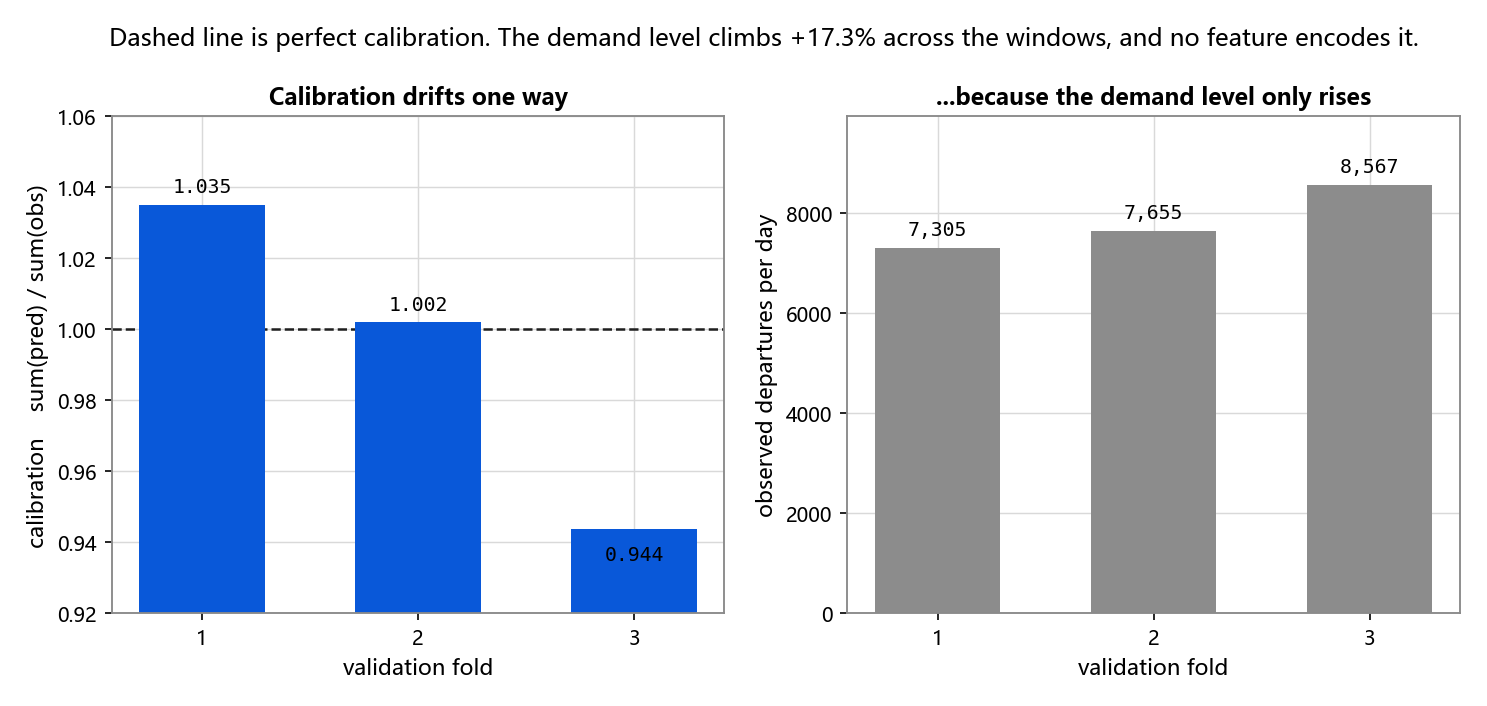

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))
xs = tf.fold.astype(str)

ax = axes[0]
ax.axhline(1.0, color=C.viz.INK, lw=1.2, ls="--", zorder=1)
ax.bar(xs, tf.calibration, color=C.viz.BLUE, width=.58, zorder=2)
for xi, v in zip(xs, tf.calibration):
    ax.annotate(f"{v:.3f}", (xi, v), textcoords="offset points",
                xytext=(0, 6 if v >= 1 else -15), ha="center",
                fontsize=9.5, family="monospace")
ax.set_ylim(min(0.92, tf.calibration.min() - 0.02),
            max(1.06, tf.calibration.max() + 0.02))
ax.set_xlabel("validation fold")
ax.set_ylabel("calibration    sum(pred) / sum(obs)")
ax.set_title("Calibration drifts one way", fontsize=11, weight="semibold")

ax = axes[1]
ax.bar(xs, tf.obs_per_day, color=C.viz.GREY, width=.58, zorder=2)
for xi, v in zip(xs, tf.obs_per_day):
    ax.annotate(f"{v:,.0f}", (xi, v), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=9.5, family="monospace")
ax.set_ylim(0, tf.obs_per_day.max() * 1.16)
ax.set_xlabel("validation fold")
ax.set_ylabel("observed departures per day")
ax.set_title("...because the demand level only rises", fontsize=11, weight="semibold")

fig.suptitle(f"Dashed line is perfect calibration. The demand level climbs "
             f"{lift:+.1f}% across the windows, and no feature encodes it.",
             fontsize=11.5, y=1.02)
show(fig, "nb_fig02_calibration.png")

## 7. 误差在一天里的位置

按时段拆开看，误差不是均匀分布的。

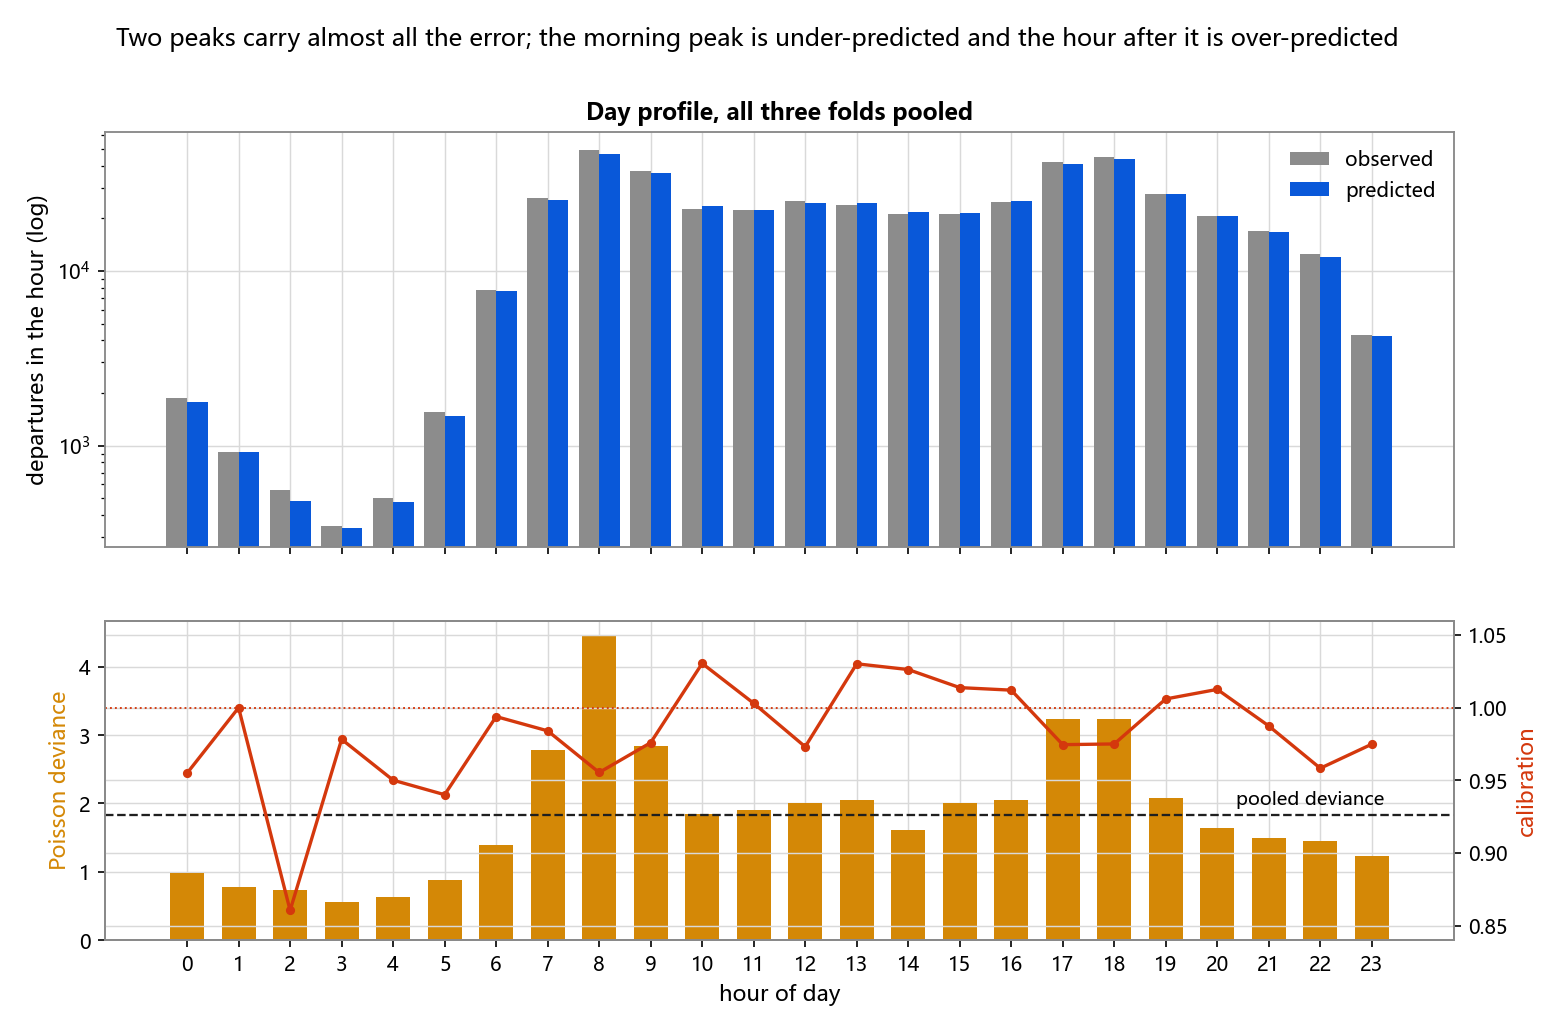

In [9]:
by_hour = preds.groupby("hour").apply(
    lambda d: pd.Series({"obs": d.actual.sum(), "pred": d.pred.sum(),
                         **C.metrics(d.actual, d.pred)}),
    include_groups=False).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11.6, 7.0), sharex=True,
                         height_ratios=[1.3, 1.0])

ax = axes[0]
w = 0.4
ax.bar(by_hour.hour - w / 2, by_hour.obs, width=w, color=C.viz.GREY,
       label="observed", zorder=2)
ax.bar(by_hour.hour + w / 2, by_hour.pred, width=w, color=C.viz.BLUE,
       label="predicted", zorder=2)
ax.set_yscale("log")
ax.set_ylabel("departures in the hour (log)")
ax.legend(frameon=False, fontsize=9.5)
ax.set_title("Day profile, all three folds pooled", fontsize=11, weight="semibold")

ax = axes[1]
ax.bar(by_hour.hour, by_hour.poisson_deviance, color=C.viz.AMBER, width=.66,
       zorder=2)
ax.axhline(pooled_metrics["poisson_deviance"], color=C.viz.INK, lw=1.1, ls="--",
           zorder=3)
ax.annotate("pooled deviance", (23.4, pooled_metrics["poisson_deviance"]),
            textcoords="offset points", xytext=(-4, 5), ha="right", fontsize=9)
ax.set_xlabel("hour of day")
ax.set_ylabel("Poisson deviance", color=C.viz.AMBER)
ax.set_xticks(range(24))

ax2 = ax.twinx()
ax2.plot(by_hour.hour, by_hour.calibration, color=C.viz.RED, lw=1.6, marker="o",
         ms=3.4, zorder=4)
ax2.axhline(1.0, color=C.viz.RED, lw=.9, ls=":", zorder=1)
ax2.set_ylabel("calibration", color=C.viz.RED)
ax2.set_ylim(0.84, 1.06)

fig.suptitle("Two peaks carry almost all the error; the morning peak is "
             "under-predicted and the hour after it is over-predicted",
             fontsize=11.5, y=0.98)
show(fig, "nb_fig03_by_hour.png")

### 读图

- 上下两个峰是 **7–9 点（早高峰）和 17–18 点（晚高峰）**，它们贡献了绝大部分
  deviance；凌晨 3 点的 deviance 只有 0.555。
- 红线（校准）在早高峰呈现**「先低估、后高估」**：8 点 0.955、9 点 0.976、10 点 1.030。
  也就是说模型把**早高峰的爬升时机**判断偏晚了 —— `lag1` 这个特征没能把它拎起来。
- 这一点运营上有直接含义：早高峰缺车正是最贵的时段，而模型恰好在 8 点系统性偏少。

## 8. 均值收缩：模型把极端往中间拉

按实际计数量级分箱，看每一档的预测总量和平均偏差。这是这类模型最典型的失效模式。

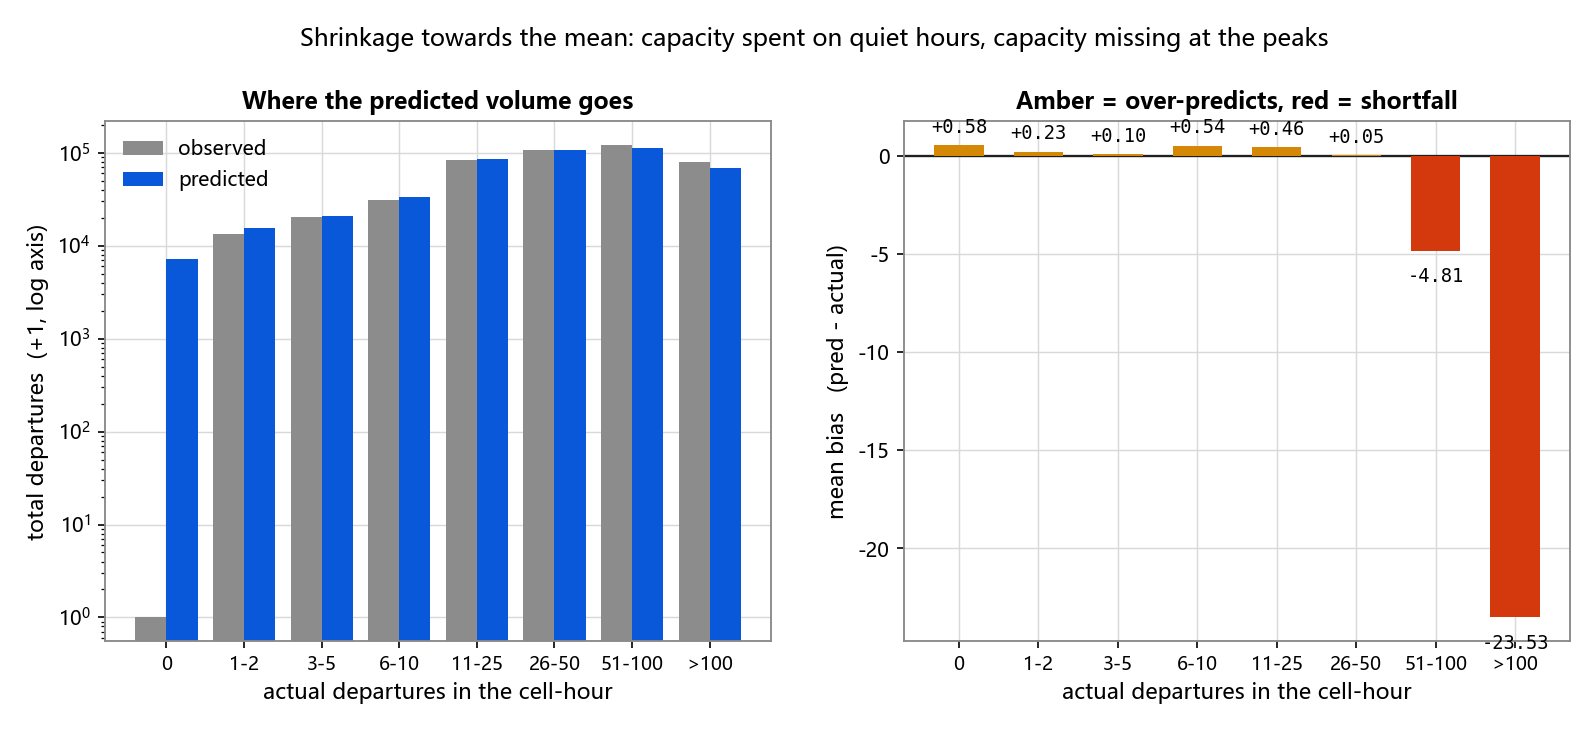

,band,rows,share,mae,poisson_deviance,pred_sum,obs_sum,calibration,bias
0,0,12550.0,0.301,0.577,1.153,7236.576,0.0,NaN,0.577
1,1-2,9647.0,0.231,0.910,0.933,15529.062,13319.0,1.166,0.229
2,3-5,5317.0,0.127,2.024,1.756,20751.789,20237.0,1.025,0.097
3,6-10,4011.0,0.096,3.107,2.106,33067.365,30918.0,1.070,0.536
4,11-25,5027.0,0.120,4.859,2.395,85614.328,83291.0,1.028,0.462
5,26-50,2938.0,0.070,7.712,2.942,107400.607,107266.0,1.001,0.046
6,51-100,1835.0,0.044,10.970,3.585,112534.793,121361.0,0.927,-4.810
7,>100,435.0,0.010,33.474,18.066,68965.326,79199.0,0.871,-23.526


In [10]:
BINS = [-1, 0, 2, 5, 10, 25, 50, 100, 10 ** 9]
LABELS = ["0", "1-2", "3-5", "6-10", "11-25", "26-50", "51-100", ">100"]
preds["band"] = pd.cut(preds.actual, bins=BINS, labels=LABELS)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)   # actual=0 那一档 obs_sum 为 0
    bands = preds.groupby("band", observed=True).apply(
        lambda d: pd.Series({"rows": len(d), **C.metrics(d.actual, d.pred)}),
        include_groups=False).reset_index()
bands.loc[bands.obs_sum == 0, "calibration"] = np.nan
bands["share"] = bands.rows / len(preds)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.5))
x = np.arange(len(bands))
w = 0.4

ax = axes[0]
ax.bar(x - w / 2, bands.obs_sum + 1, width=w, color=C.viz.GREY,
       label="observed", zorder=2)
ax.bar(x + w / 2, bands.pred_sum + 1, width=w, color=C.viz.BLUE,
       label="predicted", zorder=2)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(bands.band, fontsize=9)
ax.set_xlabel("actual departures in the cell-hour")
ax.set_ylabel("total departures  (+1, log axis)")
ax.legend(frameon=False, fontsize=9.5)
ax.set_title("Where the predicted volume goes", fontsize=11, weight="semibold")

ax = axes[1]
ax.axhline(0, color=C.viz.INK, lw=1.1, zorder=1)
ax.bar(x, bands.bias, width=.62,
       color=[C.viz.RED if v < 0 else C.viz.AMBER for v in bands.bias], zorder=2)
for xi, v in zip(x, bands.bias):
    ax.annotate(f"{v:+.2f}", (xi, v), textcoords="offset points",
                xytext=(0, 6 if v >= 0 else -15), ha="center",
                fontsize=9, family="monospace")
ax.set_xticks(x)
ax.set_xticklabels(bands.band, fontsize=9)
ax.set_xlabel("actual departures in the cell-hour")
ax.set_ylabel("mean bias   (pred - actual)")
ax.set_title("Amber = over-predicts, red = shortfall", fontsize=11,
             weight="semibold")

fig.suptitle("Shrinkage towards the mean: capacity spent on quiet hours, "
             "capacity missing at the peaks", fontsize=11.5, y=1.02)
show(fig, "nb_fig04_count_band.png")

display(bands[["band", "rows", "share", "mae", "poisson_deviance", "pred_sum",
               "obs_sum", "calibration", "bias"]].round(3))

### 读图

- `actual = 0` 那一档占**全部行的 30.1%**，模型在上面平均花掉 **0.577 辆**的预测
  （bias +0.577，对应图 1 里 `x=1` 那道竖带）。这些容量花在了什么都没发生的地方。
- `>100` 那一档只占 **1.04%** 的行，却低估 **23.5 辆/行**：实际 79,199 辆里漏掉 10,234 辆，
  **相当于该档需求的 12.9%**。
- 中间几档（2-5、25-50）偏差很小，说明模型不是整体偏，而是**把两端的极值往中间压**。
- 这一档的 `calibration` 是 NaN 而不是数字：分母 `obs_sum` 为 0，是分箱的产物，不是模型
  的问题。看 `bias` 就够了。
- **方向对运营不利**：最贵的时段（高峰）缺，最便宜的时候（空档）多。

## 9. 误差在格子上的位置

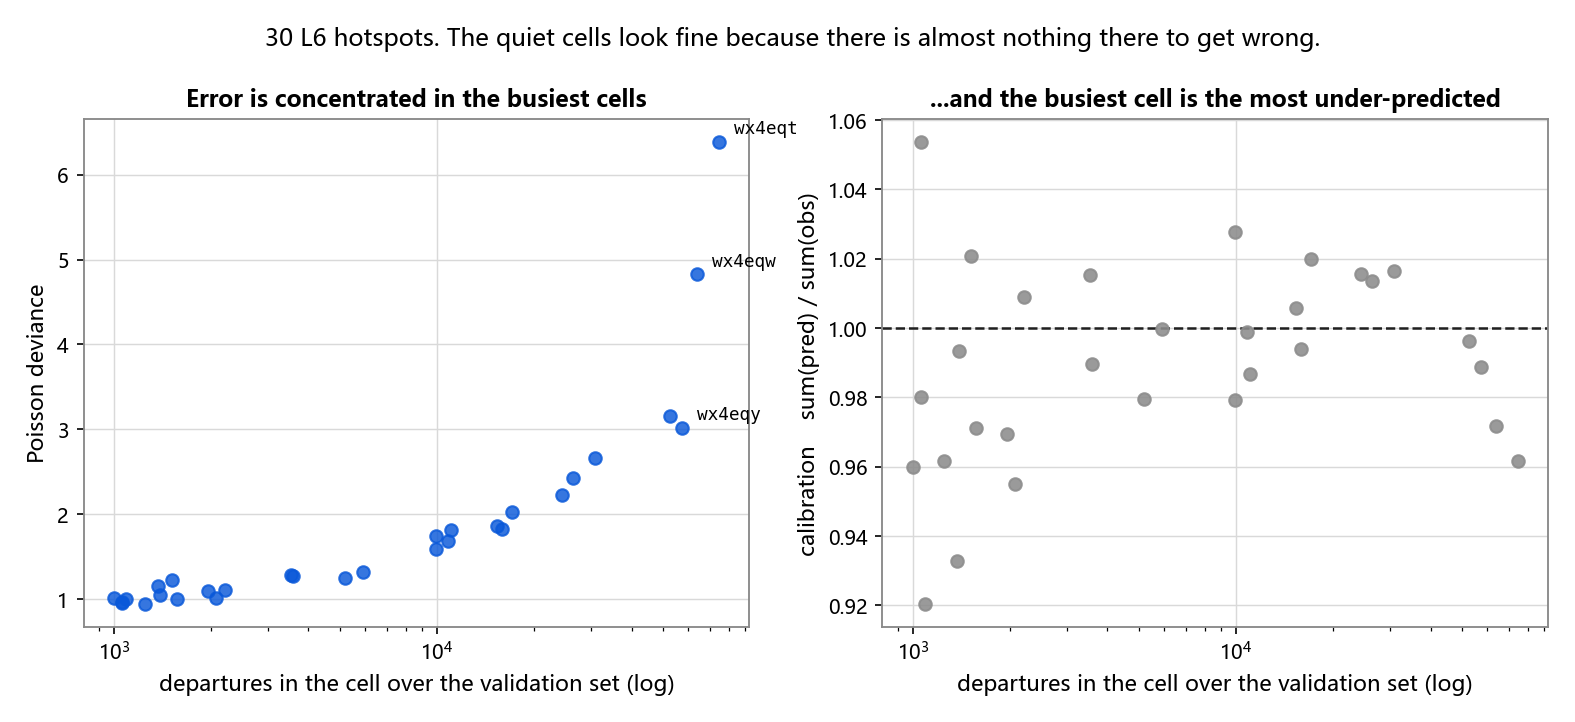

,cell,obs_sum,mae,poisson_deviance,calibration,bias,pred_max
8,wx4eqt,74602.0,11.592,6.388,0.962,-2.055,401.713
11,wx4eqw,63864.0,9.747,4.825,0.972,-1.296,303.293
13,wx4eqy,57425.0,7.715,3.020,0.989,-0.458,195.580
10,wx4eqv,52496.0,7.432,3.158,0.996,-0.143,156.069
18,wx4erj,30847.0,5.468,2.658,1.016,0.363,186.059
21,wx4ern,26310.0,4.819,2.428,1.014,0.257,92.413
9,wx4equ,24289.0,4.557,2.228,1.016,0.274,58.942
7,wx4eqs,17062.0,3.611,2.023,1.020,0.243,43.952


...


,cell,obs_sum,mae,poisson_deviance,calibration,bias,pred_max
25,wx4ert,1247.0,0.678,0.942,0.962,-0.034,4.691
1,wx4eqc,1094.0,0.649,0.999,0.920,-0.062,3.659
4,wx4eqf,1062.0,0.619,0.955,0.980,-0.015,3.101
24,wx4err,1060.0,0.632,0.964,1.054,0.041,4.144
29,wx4ex2,1000.0,0.631,1.016,0.960,-0.029,3.403


In [11]:
by_cell = preds.groupby("cell").apply(
    lambda d: pd.Series({"obs_sum": d.actual.sum(), **C.metrics(d.actual, d.pred)}),
    include_groups=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.scatter(by_cell.obs_sum, by_cell.poisson_deviance, s=36, color=C.viz.BLUE,
           alpha=.82, zorder=2)
ax.set_xscale("log")
for _, r in by_cell.nlargest(3, "obs_sum").iterrows():
    ax.annotate(r.cell, (r.obs_sum, r.poisson_deviance),
                textcoords="offset points", xytext=(7, 4), fontsize=8.5,
                family="monospace")
ax.set_xlabel("departures in the cell over the validation set (log)")
ax.set_ylabel("Poisson deviance")
ax.set_title("Error is concentrated in the busiest cells", fontsize=11,
             weight="semibold")

ax = axes[1]
ax.axhline(1.0, color=C.viz.INK, lw=1.2, ls="--", zorder=1)
ax.scatter(by_cell.obs_sum, by_cell.calibration, s=36, color=C.viz.GREY,
           alpha=.88, zorder=2)
ax.set_xscale("log")
ax.set_xlabel("departures in the cell over the validation set (log)")
ax.set_ylabel("calibration    sum(pred) / sum(obs)")
ax.set_title("...and the busiest cell is the most under-predicted", fontsize=11,
             weight="semibold")

fig.suptitle("30 L6 hotspots. The quiet cells look fine because there is almost "
             "nothing there to get wrong.", fontsize=11.5, y=1.02)
show(fig, "nb_fig05_by_cell.png")

tbl = by_cell.sort_values("obs_sum", ascending=False)[
    ["cell", "obs_sum", "mae", "poisson_deviance", "calibration", "bias", "pred_max"]]
display(tbl.head(8).round(3))
print("...")
display(tbl.tail(5).round(3))

### 读图

- **误差几乎全部集中在头部格子。** 最大那个格 `wx4eqt` 贡献了约 16.4% 的实际出发量，deviance 6.39
  （池化值的 3.5 倍），且是低估最严重的（bias -2.05 辆/小时）。
- **尾部 5 个格子的 deviance 都在 1.0 附近、校准接近 1** —— 它们本来就只有零星几辆，
  模型基本在输出常数。指标好看，不代表模型在那儿有用。
- 这正好印证 §H 里「只取 top-30 热点」这个选择：低量格子会把均值型汇总指标稀释掉。

## 10. 极值个案

把偏差最大的几条抓出来，可以直接当 slide 上的例子。

In [12]:
preds["err"] = preds.pred - preds.actual
COLS = ["fold", "cell", "date", "hour", "actual", "pred", "err"]

print("低估 top 5（漏掉的量最大）")
display(preds.nsmallest(5, "err")[COLS].round(3))
print("高估 top 5（多余的量最大）")
display(preds.nlargest(5, "err")[COLS].round(3))

低估 top 5（漏掉的量最大）


,fold,cell,date,hour,actual,pred,err
31352,3,wx4eqt,2026-05-11,8,495,123.543,-371.457
4040,1,wx4eqt,2026-04-13,8,378,78.683,-299.317
31376,3,wx4eqt,2026-05-12,8,456,189.756,-266.244
5418,1,wx4eqw,2026-04-13,18,316,91.354,-224.646
31304,3,wx4eqt,2026-05-09,8,324,112.900,-211.100


高估 top 5（多余的量最大）


,fold,cell,date,hour,actual,pred,err
3872,1,wx4eqt,2026-04-06,8,29,249.213,220.213
3944,1,wx4eqt,2026-04-09,8,126,295.167,169.167
31617,3,wx4eqt,2026-05-22,9,62,212.075,150.075
19074,2,wx4eqw,2026-05-01,18,64,211.607,147.607
32921,3,wx4eqw,2026-05-16,17,69,211.228,142.228


低估和高估全部落在**同一个格的同一个小时**（`wx4eqt` 早 8 点、`wx4eqw` 晚 18 点），
只是方向不同。这两处是全数据集里方差最大的 cell-hour，`lag1` / `lag24` 在这里既可能
指向暴涨也可能指向暴跌 —— 与其说是模型错，不如说是这个格子在这个小时上**本来就难以
预测**。

## 11. 结论（可以直接进 deck 的四条）

1. **预测偏差随时间单向漂移：+3.5% -> +0.2% -> -5.6%。** 三个验证窗口的日均需求是
   7,305 / 7,655 / 8,567，最后一个比第一个高 **17.3%**。特征集里**没有趋势项、也没有
   天气**，所以模型一直在用过去的水平预测更高的未来。**这是全表最有信息量的一条**，
   而且它就是 limitation 里「没有天气」的量化形式。

2. **主要失效模式是均值收缩，方向对运营不利。** 在占 30.1% 的「零出发」行上平均浪费
   0.577 辆的预测，同时漏掉峰值段（>100 辆/小时）12.9% 的需求。

3. **误差不是均匀分布的。** 集中在 30 个格里的头 1 个（`wx4eqt` 一个格就占 16.4% 的
   出发量、deviance 是池化值的 3.5 倍）、24 小时里的 4 个（7-9、17-18）。均值型汇总
   指标（MAE 2.90）会把这个结构完全抹平 —— 这也是为什么残差地图值得画。

4. **XGBoost 的预测上界从未越过实测上界**（402 vs 495），而 `nb_glm` 越到 1,082。这是
   两个模型之间**可操作性**的区别，不只是准确率上的区别。

## 12. 往下可以做的

- 把 §E 已经算出来但没喂进模型的失衡信号（净流、角色反转）补成特征。
- 处理 §G 的截尾：现在预测的是「实际发生」而不是「潜在需求」，这是天花板的一半。
- 加天气与节假日 —— 第 1 条结论说得很清楚，这是最直接的补法。
